# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [13]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
penguins = sns.load_dataset('penguins')

In [5]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [9]:
# Verificar nulos
print("Nulos por coluna:")
print(penguins.isnull().sum())

# Remover nulos
penguins = penguins.dropna()

# Remover colunas categoricas
# Remover colunas categoricas
penguins_num = penguins.drop(columns=['species', 'island', 'sex'])

print("Shape apos tratamento:", penguins_num.shape)
print(penguins_num.head())

Nulos por coluna:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
Shape apos tratamento: (333, 4)
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            39.1           18.7              181.0       3750.0
1            39.5           17.4              186.0       3800.0
2            40.3           18.0              195.0       3250.0
4            36.7           19.3              193.0       3450.0
5            39.3           20.6              190.0       3650.0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

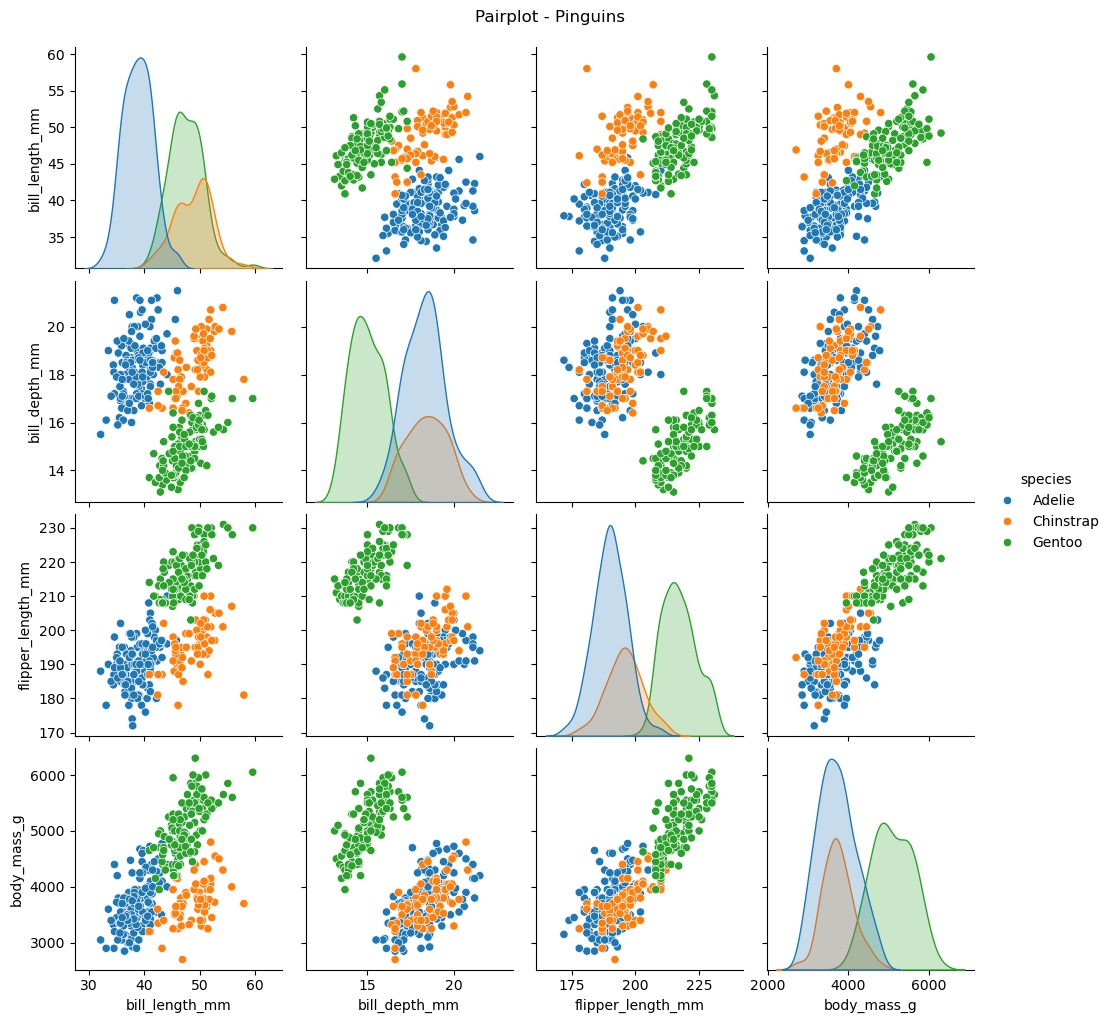

In [17]:

# Pairplot com as especies coloridas para comparar depois
sns.pairplot(penguins.dropna(), hue='species', vars=[
    'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'
])
plt.suptitle('Pairplot - Pinguins', y=1.02)
plt.show()

### Etapa 2 - Pairplot

Sim, e possivel identificar agrupamentos visualmente.
Sao visiveis 3 grupos distintos, correspondendo as
3 especies de pinguins.

Os melhores graficos para identificar os grupos sao:

- flipper_length_mm x body_mass_g: Gentoo (verde) se
  separa claramente dos outros dois com barbatanas maiores
  e maior massa corporal.

- bill_length_mm x bill_depth_mm: Adelie (azul) se
  destaca com bico mais curto e profundo, enquanto
  Chinstrap (laranja) e Gentoo (verde) tem bicos mais
  longos e rasos.

- flipper_length_mm x bill_length_mm: Gentoo se isola
  completamente no canto superior direito.

Adelie e Chinstrap sao as especies com maior sobreposicao,
sendo as mais dificeis de separar pelo modelo.

# 3 - Realize a padronização dos dados e visualize os dados.

In [20]:
scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_num)

# Visualizar
penguins_scaled_df = pd.DataFrame(penguins_scaled, columns=penguins_num.columns)
print(penguins_scaled_df.describe().round(2))
print(penguins_scaled_df.head())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean             0.00           0.00               0.00        -0.00
std              1.00           1.00               1.00         1.00
min             -2.18          -2.07              -2.07        -1.87
25%             -0.82          -0.80              -0.78        -0.82
50%              0.09           0.07              -0.28        -0.20
75%              0.84           0.78               0.86         0.71
max              2.86           2.20               2.15         2.60
   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0       -0.896042       0.780732          -1.426752    -0.568475
1       -0.822788       0.119584          -1.069474    -0.506286
2       -0.676280       0.424729          -0.426373    -1.190361
3       -1.335566       1.085877          -0.569284    -0.941606
4       -0.859415       1.747026          -0.783651   

# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [ ]:
# Aplicar KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(penguins_scaled)

# Adicionar clusters ao dataframe original
penguins_num['cluster'] = kmeans.labels_

print("Distribuicao dos clusters:")
print(penguins_num['cluster'].value_counts())

print("\nCentroides:")
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=penguins_num.drop(columns='cluster').columns
)
print(centroides.round(2))

# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [ ]:
# seu código aqui

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo: